# NYC Building Emissions Analysis in the Context of Local Law 97

Buildings account for the largest share of greenhouse gas emissions in New York City, making them a central focus of the city’s climate mitigation strategy. Local Law 97 establishes emissions limits for large buildings beginning in 2024, with increasingly stringent caps through 2030.

The goal of this analysis is to examine building-level emissions intensity using reported data from 2022 to the present, identify patterns across property types and building sizes, and identify high-emitting and inefficient buildings that may need targeted intervention.

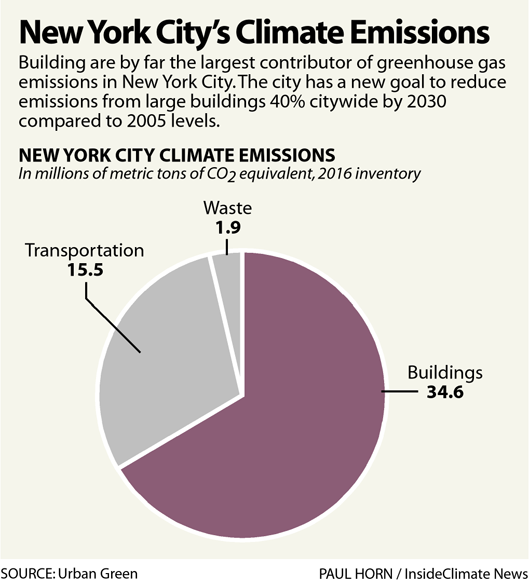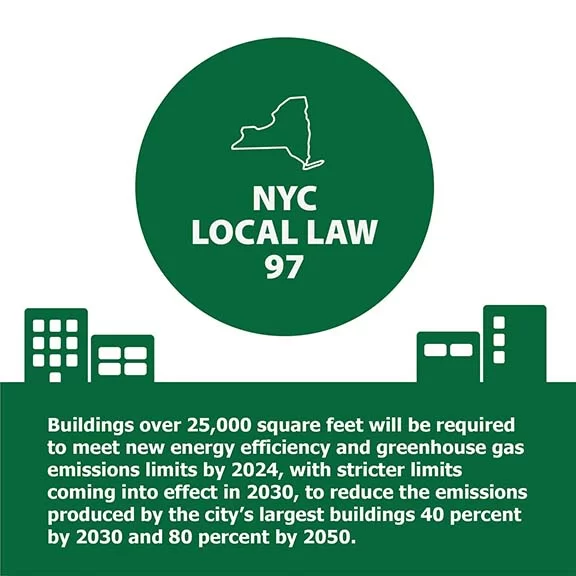

# Section 1: Data Preprocessing and Feature Engineering

# Identify and Collect (10pts)

This dataset was ingested directly from the NYC Open Data API, simulating an enterprise workflow where regulatory data is pulled from an external system into an analytics environment. An initial inspection was conducted to understand data structure, data types, and completeness before proceeding to cleaning and feature engineering.

In [ ]:
# ---------------------------------------------------
# IDENTIFY & COLLECT
# NYC Building Energy & Emissions Data (LL84 / LL97)
# Source: NYC Open Data API
# ---------------------------------------------------

import pandas as pd

# Display settings for readability
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)

# ---------------------------------------------------
# Step 1: Define API endpoint
# ---------------------------------------------------
# NOTE: Socrata APIs default to ~1000 rows.
# We explicitly request a higher limit to simulate
# enterprise-scale data ingestion.

url = "https://data.cityofnewyork.us/resource/5zyy-y8am.json?$limit=50000"

# ---------------------------------------------------
# Step 2: Load raw data from API
# ---------------------------------------------------
BuildingData_raw = pd.read_json(url)

# ---------------------------------------------------
# Step 3: Initial data inspection
# ---------------------------------------------------

print("===== RAW DATA PREVIEW =====")
display(BuildingData_raw.head())

print("\n===== DATASET SHAPE =====")
print(f"Rows: {BuildingData_raw.shape[0]}")
print(f"Columns: {BuildingData_raw.shape[1]}")

print("\n===== DATA TYPES & NON-NULL COUNTS =====")
BuildingData_raw.info()

print("\n===== NUMERIC SUMMARY (RAW DATA) =====")
display(BuildingData_raw.describe())



===== RAW DATA PREVIEW =====


,report_year,property_id,property_name,parent_property_id,parent_property_name,...,data_quality_checker_date_run,electric_distribution_utility,aggregate_meter_s_electric_number_of_individual_meters_included,aggregate_meter_s_natural_gas_number_of_individual_meters_included,aggregate_meter_s_district_steam_number_of_individual_meters_included
0,2022,6414946,58-01 Grand Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,NaN,NaN,NaN,NaN,NaN
1,2022,9793770,1870 Pelham Parkway South,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,NaN,NaN,NaN,NaN,NaN
2,2022,10177418,Central Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,NaN,NaN,NaN,NaN,NaN
3,2022,13511507,215 East 99th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,NaN,NaN,NaN,NaN,NaN
4,2022,14009907,23-25 31 Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,NaN,NaN,NaN,NaN,NaN



===== DATASET SHAPE =====
Rows: 50000
Columns: 265

===== DATA TYPES & NON-NULL COUNTS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 265 entries, report_year to aggregate_meter_s_district_steam_number_of_individual_meters_included
dtypes: float64(11), int64(10), object(244)
memory usage: 101.1+ MB

===== NUMERIC SUMMARY (RAW DATA) =====


,report_year,property_id,year_built,number_of_buildings,occupancy,...,council_district,ct2020,aggregate_meter_s_electric_number_of_individual_meters_included,aggregate_meter_s_natural_gas_number_of_individual_meters_included,aggregate_meter_s_district_steam_number_of_individual_meters_included
count,50000.000000,5.000000e+04,50000.00000,50000.000000,50000.000000,...,48226.000000,48226.000000,19515.000000,19515.0,19515.0
mean,2022.390660,1.048138e+07,1951.40386,1.312880,97.111100,...,19.761249,9040.302264,0.000820,0.0,0.0
std,0.488641,9.074186e+06,35.23728,3.995125,12.129044,...,15.004532,21734.914383,0.107614,0.0,0.0
min,2022.000000,7.365000e+03,1051.00000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.0,0.0
25%,2022.000000,3.312990e+06,1925.00000,1.000000,100.000000,...,6.000000,139.000000,0.000000,0.0,0.0
50%,2022.000000,6.699409e+06,1941.00000,1.000000,100.000000,...,16.000000,303.000000,0.000000,0.0,0.0
75%,2023.000000,1.535687e+07,1974.00000,1.000000,100.000000,...,33.000000,1903.000000,0.000000,0.0,0.0
max,2024.000000,6.607449e+07,2088.00000,514.000000,100.000000,...,51.000000,157903.000000,15.000000,0.0,0.0


To support enterprise-level ESG and compliance decision-making, the dataset was reduced from over 300 raw fields to a focused set of identifiers, building characteristics, energy metrics, emissions indicators, and data quality flags. Columns that did not directly support risk assessment, prioritization, or reporting workflows were intentionally excluded to create a decision-ready data mart.

**Final Data mart will look like this:**
property_id, report_year, borough, property_type, floor_area, energy_use, emissions, emissions_intensity, energy_star, compliance_status, risk_tier

# Clean and Prepare (10pts)

In [ ]:
# ---------------------------------------------------
# CLEAN & PREPARE: Create working copy
# ---------------------------------------------------

BuildingData = BuildingData_raw.copy()

In [ ]:
# ---------------------------------------------------
# CLEAN & PREPARE: Column Selection (Data Mart Inputs)
# ---------------------------------------------------

columns_to_keep = [
    # ----------------------------
    # Identifiers
    # ----------------------------
    "report_year",
    "property_id",
    "property_name",
    "parent_property_id",
    "parent_property_name",
    "nyc_borough_block_and_lot",
    "nyc_building_identification",

    # ----------------------------
    # Location & Segmentation
    # ----------------------------
    "borough",
    "postal_code",
    "community_board",
    "latitude",
    "longitude",

    # ----------------------------
    # Building Characteristics
    # ----------------------------
    "primary_property_type",
    "largest_property_use_type",
    "year_built",
    "construction_status",
    "number_of_buildings",
    "occupancy",

    # ----------------------------
    # Floor Area (keep both for QA)
    # ----------------------------
    "property_gfa_self_reported",
    "property_gfa_calculated",

    # ----------------------------
    # Core Energy Metrics
    # ----------------------------
    "site_energy_use_kbtu",
    "weather_normalized_site_energy",
    "electricity_use_grid_purchase",
    "natural_gas_use_kbtu",
    "district_steam_use_kbtu",

    # ----------------------------
    # Core Emissions Metrics
    # ----------------------------
    "total_location_based_ghg",
    "direct_ghg_emissions_metric",
    "indirect_location_based_ghg",
    "net_emissions_metric_tons",
    "direct_ghg_emissions_intensity",

    # ----------------------------
    # ENERGY STAR (optional but valuable)
    # ----------------------------
    "energy_star_score",
    "energy_star_certification",
    "national_median_energy_star",

    # ----------------------------
    # Data Quality Flags
    # ----------------------------
    "estimated_data_flag",
    "estimated_values_energy",
    "alert_energy_meter_has_gaps",
    "alert_property_has_no_uses",

    # ----------------------------
    # Reporting & Governance Metadata
    # ----------------------------
    "report_submission_date",
    "report_generation_date",
    "last_modified_date_property"
]

# Subset the dataframe
BuildingData_selected = BuildingData[columns_to_keep].copy()

# ---------------------------------------------------
# Validation checks
# ---------------------------------------------------

print("Before column selection:", BuildingData.shape)
print("After column selection:", BuildingData_selected.shape)

BuildingData_selected.head()


Before column selection: (50000, 265)
After column selection: (50000, 40)


,report_year,property_id,property_name,parent_property_id,parent_property_name,...,alert_energy_meter_has_gaps,alert_property_has_no_uses,report_submission_date,report_generation_date,last_modified_date_property
0,2022,6414946,58-01 Grand Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,Ok,Ok,2023-04-25T11:02:00.000,2023-04-25T11:01:00.000,2023-04-24T00:00:00.000
1,2022,9793770,1870 Pelham Parkway South,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,Ok,Ok,2023-03-11T14:01:00.000,2023-03-11T14:00:00.000,2023-03-10T00:00:00.000
2,2022,10177418,Central Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,Ok,Ok,2023-04-14T15:47:00.000,2023-04-14T15:47:00.000,2023-04-14T00:00:00.000
3,2022,13511507,215 East 99th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,Ok,Ok,2023-03-12T15:54:00.000,2023-03-12T15:54:00.000,2023-03-03T00:00:00.000
4,2022,14009907,23-25 31 Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,...,Ok,Ok,2023-04-28T14:23:00.000,2023-04-28T14:22:00.000,2023-03-15T00:00:00.000


Resolving non-numeric data types

In [ ]:
# Convert Critical Numeric Fields

numeric_cols = [
    "gross_floor_area",
    "total_location_based_ghg",
    "net_emissions_metric_tons",
    "site_energy_use_kbtu",
    "total_location_based_ghg",
    "property_gfa_self_reported"
]

for col in numeric_cols:
    if col in BuildingData_selected.columns:
        BuildingData_selected[col] = pd.to_numeric(
            BuildingData_selected[col], errors="coerce"
        )


Identifying Null Values

In [ ]:
# Datatypes + non-null counts
BuildingData_selected.info()

# Exact null counts
null_summary = BuildingData_selected.isna().sum()
null_summary.sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   report_year                     50000 non-null  int64  
 1   property_id                     50000 non-null  int64  
 2   property_name                   50000 non-null  object 
 3   parent_property_id              50000 non-null  object 
 4   parent_property_name            50000 non-null  object 
 5   nyc_borough_block_and_lot       50000 non-null  object 
 6   nyc_building_identification     50000 non-null  object 
 7   borough                         48228 non-null  object 
 8   postal_code                     50000 non-null  object 
 9   community_board                 48226 non-null  float64
 10  latitude                        48225 non-null  float64
 11  longitude                       48225 non-null  float64
 12  primary_property_type           

,0
net_emissions_metric_tons,19649
last_modified_date_property,19521
site_energy_use_kbtu,2972
longitude,1775
latitude,1775
community_board,1774
borough,1772
total_location_based_ghg,1012
report_submission_date,18
property_gfa_calculated,11


Dealing with null and zero-value data

In [ ]:

# ---------------------------------------------------
# Remove rows with invalid total GHG emissions
# ---------------------------------------------------

before_rows = BuildingData_selected.shape[0]

BuildingData_selected_clean = BuildingData_selected[
    BuildingData_selected["total_location_based_ghg"] > 0
].copy()

after_rows = BuildingData_selected_clean.shape[0]

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)


Rows before: 50000
Rows after: 46849
Rows removed: 3151


In [ ]:

# ---------------------------------------------------
# Remove rows with invalid gross floor area
# ---------------------------------------------------

before_rows = BuildingData_selected_clean.shape[0]

BuildingData_selected_clean = BuildingData_selected_clean[
    BuildingData_selected_clean["property_gfa_self_reported"] > 0
].copy()

after_rows = BuildingData_selected_clean.shape[0]

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)




Rows before: 46849
Rows after: 46837
Rows removed: 12


# Feature Engineering and Data Marts (20pts)

## Gross Floor Area, A Core Metric

Gross floor area is a critical analytical field because it enables normalization of energy and emissions data, supports fair benchmarking across buildings of different sizes, and is required for emissions intensity and compliance calculations. Records without floor area were therefore excluded from downstream analysis.

Both self-reported and calculated gross floor area (GFA) values were available. An inspection of missing values showed that the self-reported gross floor area field was complete, while the calculated GFA field contained missing values. Therefore, self-reported GFA was selected as the canonical floor area metric for all subsequent analysis.

In [ ]:
# ---------------------------------------------------
# Canonical Gross Floor Area (GFA)
# ---------------------------------------------------

BuildingData_selected_clean["gross_floor_area"] = pd.to_numeric(
    BuildingData_selected_clean["property_gfa_self_reported"],
    errors="coerce"
)

# Sanity check
print(BuildingData_selected_clean["gross_floor_area"].isna().sum())


0


## Emissions, A Core Metric

Total (location-based) GHG emissions were selected as the canonical emissions metric because they represent the complete operational greenhouse gas footprint of each building, combining both direct onsite emissions and indirect emissions from purchased energy. Unlike net emissions, this metric is consistently reported across properties (no null values) and does not depend on optional offset or credit mechanisms, making it more suitable for comparative and compliance-oriented analysis.

Direct and indirect emissions were retained as supporting metrics to enable decomposition of total emissions, but were not used as the primary analytical variable.

## Emissions Intensity (GHG/SqFoot)

In [ ]:
# ---------------------------------------------------
# 2) Create emissions intensity
# ---------------------------------------------------
BuildingData_selected_clean["emissions_intensity"] = (
    BuildingData_selected_clean["total_location_based_ghg"]
    / BuildingData_selected_clean["gross_floor_area"]
)



# Sanity check
BuildingData_selected_clean["emissions_intensity"].describe()

,emissions_intensity
count,4.683700e+04
mean,5.307765e-01
std,1.403322e+01
min,3.731343e-07
25%,3.686008e-03
50%,4.843244e-03
75%,6.248836e-03
max,9.182000e+02


Emissions intensity was calculated by normalizing total (location-based) GHG emissions by gross floor area. This metric enables fair, size-adjusted comparison across buildings and highlights operational efficiency rather than absolute scale, making it suitable for benchmarking, prioritization, and compliance-oriented analysis.

In [ ]:
#
# ---------------------------------------------------
# DATA MART FREEZE
# Final, analysis-ready dataset
# ---------------------------------------------------

data_mart = BuildingData_selected_clean[[
    # Identifiers
    "report_year",
    "property_id",
    "property_name",
    "borough",
    "primary_property_type",

    # Core metrics
    "gross_floor_area",
    "total_location_based_ghg",
    "emissions_intensity",

    # Supporting context
    "energy_star_score",
    "year_built"
]].copy()


print("Final Data Mart Shape:", data_mart.shape)
print(data_mart.head())

print(data_mart.info())

Final Data Mart Shape: (46837, 10)
   report_year  property_id              property_name    borough       primary_property_type  gross_floor_area  \
0         2022      6414946         58-01 Grand Avenue     QUEENS  Non-Refrigerated Warehouse           51749.0   
1         2022      9793770  1870 Pelham Parkway South      BRONX         Multifamily Housing           52941.0   
2         2022     10177418           Central Building     QUEENS          Mixed Use Property           35196.0   
3         2022     13511507       215 East 99th Street  MANHATTAN         Multifamily Housing          107234.0   
4         2022     14009907            23-25 31 Street     QUEENS              Medical Office           75191.0   

   total_location_based_ghg  emissions_intensity energy_star_score  year_built  
0                      29.9             0.000578                96        1930  
1                     216.1             0.004082                61        1960  
2                     163.1    

After data cleaning and feature engineering, a final data mart was created containing only decision-relevant identifiers, building characteristics, and core emissions metrics. This dataset represents a frozen, analysis-ready subset used for all subsequent analysis and visualization.

# Section 2: Analysis and Visualization Use your cleaned Data Mart to tell a story through data. (30pts)


# Deep Dive Analysis

In [ ]:
corr_vars = data_mart[
    [
        "gross_floor_area",
        "total_location_based_ghg",
        "emissions_intensity"
    ]
]

corr_matrix = corr_vars.corr()
corr_matrix


,gross_floor_area,total_location_based_ghg,emissions_intensity
gross_floor_area,1.000000,0.135862,-0.016763
total_location_based_ghg,0.135862,1.000000,0.008985
emissions_intensity,-0.016763,0.008985,1.000000


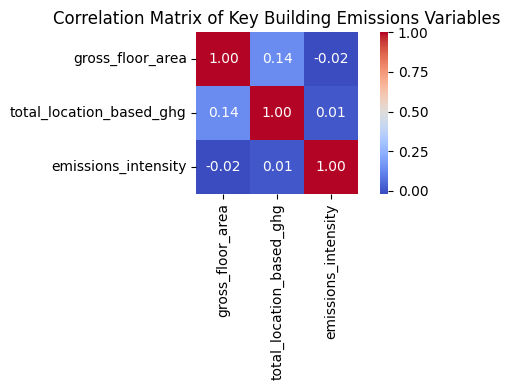

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Matrix of Key Building Emissions Variables")
plt.tight_layout()
plt.show()

Total greenhouse gas emissions are weakly positively correlated with gross floor area, while emissions intensity shows weaker correlation with size, reinforcing the importance of size-normalized metrics for performance comparison.

ANALYSIS 1: Distribution of Emissions Intensity

Question: How are buildings distributed in terms of emissions efficiency?

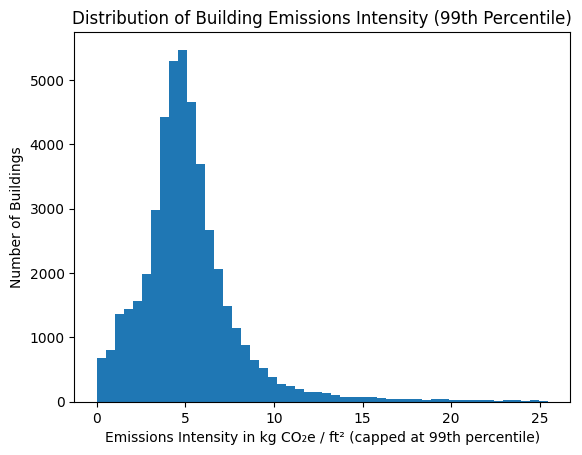

In [ ]:
from matplotlib import pyplot as plt

data_mart["emissions_intensity_kg_per_ft2"] = data_mart["emissions_intensity"] * 1000

upper_cap = data_mart["emissions_intensity_kg_per_ft2"].quantile(0.99)

plt.figure()
plt.hist(
    data_mart.loc[data_mart["emissions_intensity_kg_per_ft2"] <= upper_cap, "emissions_intensity_kg_per_ft2"],
    bins=50
)
plt.xlabel("Emissions Intensity in kg CO₂e / ft² (capped at 99th percentile)")
plt.ylabel("Number of Buildings")
plt.title("Distribution of Building Emissions Intensity (99th Percentile)")
plt.show()


Emissions intensity shows a right-skewed distribution, indicating that while most buildings operate within a moderate efficiency range, a small subset of properties exhibit disproportionately high emissions per square foot.

Most buildings are relatively efficient, but a small number are extreme outliers and dominate emissions intensity risk.

A logarithmic scale is used to reveal variation across the full distribution and highlight these high-intensity outliers.

To improve interpretability for the majority of buildings, emissions intensity values were capped at the 99th percentile. The resulting distribution shows a clear right skew, indicating that while most buildings operate within a relatively tight efficiency range, a small subset of properties exhibit substantially higher emissions per square foot.

### ANALYSIS 2: Emissions Intensity by Property Type

### Question: How does emissions efficiency vary by Property Type?

<Figure size 1000x500 with 0 Axes>

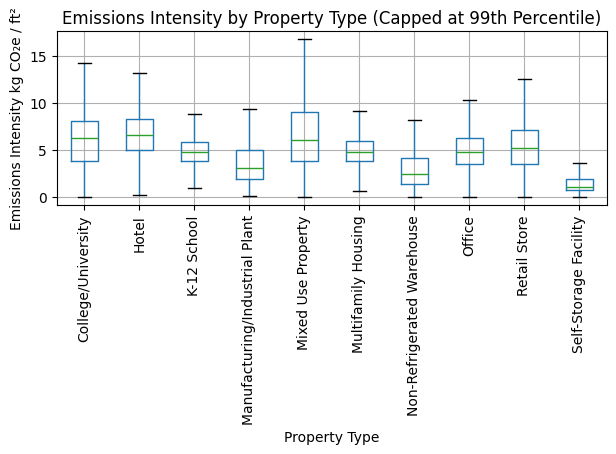

In [ ]:


top_types = (
    data_mart["primary_property_type"]
    .value_counts()
    .head(10)
    .index
)

plot_data = data_mart[
    data_mart["primary_property_type"].isin(top_types)
].copy()

# Cap for visualization only (keeps plot readable)
cap = plot_data["emissions_intensity_kg_per_ft2"].quantile(0.99)
plot_data = plot_data[plot_data["emissions_intensity_kg_per_ft2"] <= cap]

plt.figure(figsize=(10, 5))
plot_data.boxplot(
    column="emissions_intensity_kg_per_ft2",
    by="primary_property_type",
    showfliers=False,   # hides remaining outliers
    rot=90
)
plt.xlabel("Property Type")
plt.ylabel("Emissions Intensity kg CO₂e / ft²")
plt.title("Emissions Intensity by Property Type (Capped at 99th Percentile)")
plt.suptitle("")
plt.tight_layout()
plt.show()


Emissions intensity varies notably across property types, with some categories showing higher median intensity and wider variability. This suggests that building use is a key driver of operational emissions efficiency and highlights property types that may benefit from targeted interventions.

After capping emissions intensity at the 99th percentile to reduce the influence of extreme outliers, clear differences in median emissions intensity and variability emerge across property types. Mixed-use properties, hotels, and office buildings show higher median intensity and wider spread, while self-storage and non-refrigerated warehouses exhibit lower and more consistent emissions intensity.

### ANALYSIS 3: Building Size vs Total GHG Emissions

### Question: Do larger buildings emit more greenhouse gases in absolute terms?

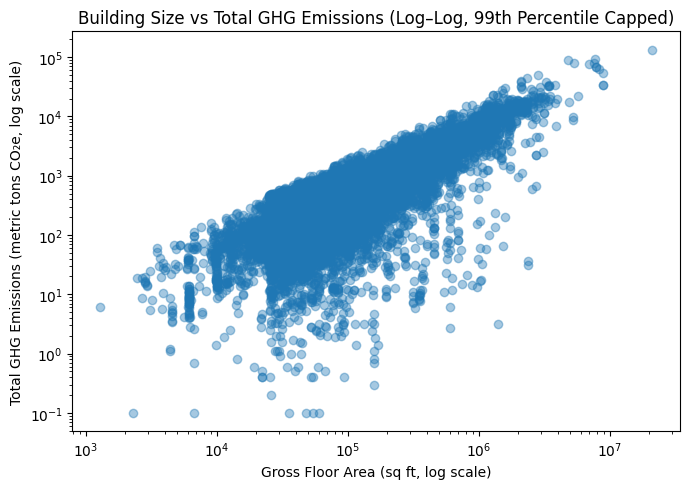

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(
    plot_data["gross_floor_area"],
    plot_data["total_location_based_ghg"],
    alpha=0.4
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gross Floor Area (sq ft, log scale)")
plt.ylabel("Total GHG Emissions (metric tons CO₂e, log scale)")
plt.title("Building Size vs Total GHG Emissions (Log–Log, 99th Percentile Capped)")
plt.tight_layout()
plt.show()


Both axes are plotted on a logarithmic scale to accommodate the wide range of building sizes and emissions values. Points appearing near the axes represent very small but non-zero values; all records with zero or non-positive floor area or emissions were removed prior to visualization.

The log–log visualization capped at the 99th percentile was selected for final analysis because it more clearly represents the relationship between building size and total emissions across several orders of magnitude while preserving interpretability.

### ANALYSIS 4: Highest Emissions Intensity Buildings


### Objective: Identify buildings with the highest emissions intensity (inefficient emitters), not just the largest emitters.

In [ ]:
filtered_data = data_mart[data_mart["gross_floor_area"] > 50000].copy()

analysis_4 = (
    filtered_data[
        [
            "property_id",
            "property_name",
            "primary_property_type",
            "borough",
            "gross_floor_area",
            "total_location_based_ghg",
            "emissions_intensity"
        ]
    ]
    .sort_values(by="emissions_intensity", ascending=False)
    .head(10)
)

# Optional: add a more interpretable unit (kgCO2e/ft²)
analysis_4["emissions_intensity_kg_per_ft2"] = analysis_4["emissions_intensity"] * 1000

analysis_4


,property_id,property_name,primary_property_type,borough,gross_floor_area,total_location_based_ghg,emissions_intensity,emissions_intensity_kg_per_ft2
31977,6720128,St. Barnabas Nursing Home 1,Senior Living Community,BRONX,84247.0,3139711.6,37.267934,37267.933576
39230,2054784,UNICEF HOUSE,Office,MANHATTAN,208203.0,181055.3,0.869609,869.609468
8670,2610789,North Shore Towers (Campus),Multifamily Housing,QUEENS,2738675.0,2206862.8,0.805814,805.814052
28506,21354394,DOC_9202_Rikers Island Bakery,Food Service,QUEENS,111450.0,68508.3,0.614700,614.699865
15104,5863726,2701 W 6th St,Energy/Power Station,BROOKLYN,63600.0,32760.2,0.515097,515.097484
7493,3105049,Mudd,College/University,NaN,287737.0,102679.2,0.356851,356.850874
18288,2826188,Warren Weaver Hall,College/University,MANHATTAN,178324.0,62661.2,0.351390,351.389605
42722,2826188,Warren Weaver Hall,College/University,MANHATTAN,178324.0,62449.6,0.350203,350.203001
34727,8726877,Pratt S.I. Campus - Total,Manufacturing/Industrial Plant,STATEN IS,438530.0,144419.3,0.329326,329.325930
9736,8726877,Pratt S.I. Campus - Total,Manufacturing/Industrial Plant,STATEN IS,438530.0,133621.3,0.304703,304.702757


Initial rankings were dominated by records with unrealistically small gross floor area values (e.g., 1 ft²), which artificially inflated emissions intensity. To avoid distorted results and focus on operationally meaningful buildings, a minimum gross floor area threshold was applied before ranking. Emissions intensity is reported as metric tons CO₂e per ft² (and also converted to kgCO₂e/ft² for interpretability). NYC Local Law 84 intensities are often reported in kgCO₂e/ft²

A minimum gross floor area threshold of 50,000 square feet was applied to exclude very small or anomalous properties whose reported floor area would disproportionately inflate emissions intensity values. This cutoff preserves a large, representative sample of operationally significant buildings while improving the interpretability and stability of the intensity-based ranking.

# Visualizations

Processed above and screenshots included in report.

# Section 3: Workflow Design



The workflow was designed to support automated, repeatable analysis of building-level greenhouse gas emissions for periodic reporting. Data is sourced from the NYC Open Data API, cleaned and validated to address data quality issues, transformed into analysis-ready metrics, and analyzed to surface portfolio-level insights and high-priority intervention candidates. The modular structure allows the pipeline to be extended toward intelligent monitoring systems, such as anomaly detection, compliance screening, or trend-based alerts.

# Next Steps

**Comparing Metrics to LL97 Emissions Cap Mandates:**

Metrics such as emissions intensity are directly relevant to emerging building performance regulations in New York City, including Local Law 97, which emphasize size-normalized emissions and targeted intervention for high-emitting properties.

**Temporal Analysis:**

Although the dataset spans multiple reporting years, this analysis focuses on a snapshot of reported building performance rather than year-over-year trends. This approach reflects common enterprise use cases, where the most recent available data is used to assess current risk and prioritize interventions.

**Towards an intelligent system:**

*   Add anomaly detection for sudden emissions spikes
*   Flag buildings exceeding intensity thresholds
*   Integrate year-over-year trend monitoring
*   Trigger alerts for regulatory review (e.g., LL97)








# Section 4: Executive Summary

Executive Summary

This project analyzes building-level greenhouse gas (GHG) emissions reported under New York City’s Local Law 84 program to assess emissions patterns, efficiency differences, and priority intervention opportunities across the city’s building stock. Using a structured analytics workflow and size-normalized metrics, the analysis highlights how emissions performance varies not only by building size, but also by property type and operational characteristics.

Key Insights

Emissions are highly concentrated among a subset of buildings.

A small number of properties account for disproportionately high total emissions. For example, North Shore Towers (Campus) in Queens reports over 2.2 million metric tons of CO₂e, illustrating how large residential complexes can dominate absolute emissions totals due to scale alone.


Building size explains total emissions—but not efficiency.

While total emissions increase with gross floor area, buildings of comparable size often exhibit markedly different emissions outcomes. For instance, UNICEF House in Manhattan and St. Barnabas Nursing Home 1 in the Bronx differ substantially in emissions intensity despite both being institutional properties, highlighting the role of operational efficiency and energy use patterns beyond size.


Emissions intensity varies meaningfully by property type.

Mixed-use, hotel, and office properties exhibit higher median emissions intensity and greater variability compared to warehouse, storage, and certain residential categories. These differences reflect operational complexity and energy-use profiles rather than building size alone.
Emissions intensity surfaces high-priority intervention candidates.


Ranking buildings by emissions intensity reveals inefficient performers that would not be flagged using total emissions alone.
St. Barnabas Nursing Home 1 exhibits an emissions intensity of approximately 37 kg CO₂e per square foot, far exceeding other large buildings in the dataset, suggesting a strong candidate for targeted energy efficiency or retrofit interventions.
Inefficiency spans multiple property types.
High emissions intensity is observed across diverse categories, including senior living facilities, offices, food service operations, and institutional campuses. Buildings such as DOC_9202_Rikers Island Bakery and Pratt S.I. Campus – Total demonstrate that inefficiency is not confined to a single sector, reinforcing the need for tailored, property-specific mitigation strategies.


Business and Policy Relevance

These findings underscore the importance of emissions intensity as a decision-making metric for prioritizing interventions under New York City’s evolving building emissions framework. By identifying inefficient buildings alongside large emitters, this analysis provides a data-driven foundation for targeting operational improvements, supporting regulatory preparedness, and allocating retrofit resources more effectively.
